# Outcome ceiling: how predictable is tournament outcome from composition alone?

**Gate question (v2 Stage 3).** Before building any composition-only goodness model, measure its predictive ceiling. If two pilots bring the *same* composition to events and their outcomes are uncorrelated, no function of composition — Bradley-Terry, fitness field, anything — can predict outcome. The **uncontrolled roster-level ICC** (intraclass correlation of outcomes across pilots of the same composition) is that ceiling.

Player names are deliberately **not** controlled for: skill-mediated team selection ("strong players pick team X") is usable signal for a goodness model, not a confound to remove. The ceiling we want is for the uncontrolled prediction problem the model will actually face.

Three measurements:

1. **Pooled ICC** at four granularities — exact roster, archetype signature (+J), role signature (−J), dominant archetype — of within-event placement percentile (and win rate). Coarser granularity trades resolution for statistical power (more pilots per group).
2. **Time-windowed ICC** — pooled ICC is optimistic under meta drift (a roster's "goodness" varies over the regulation, and validation will be out-of-time).
3. **In-person match analog** — how much match-outcome variance is composition-attributable, plus a count of how much $\Delta J$ pair support the match corpus actually has. This is the ceiling specific to the Bradley-Terry path (Stage 4's preferred label) and decides field-only $\Delta h$ vs. pairwise $\Delta J$.

**Gate:** negligible ceiling → stop, write the null result up for `/science`. Meaningful ceiling → Stage 4.


In [1]:
from __future__ import annotations

import itertools
from collections import Counter, defaultdict

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy.stats import rankdata
from IPython.display import Markdown, display

from k2dex import tournament_ingest
from k2dex.loaders import build_species_item_model

RNG_SEED = 42      # permutation nulls
LOUVAIN_SEED = 0   # matches j_communities.ipynb: same fit + same seed -> identical partition
N_PERMUTATIONS = 500
REGULATION = "M-A"

tournaments = tournament_ingest.load_cached_tournaments(regulation=REGULATION)
print(f"tournaments: {len(tournaments)}")
print(f"teams:       {sum(len(t.teams) for t in tournaments)}")
print(f"matches:     {sum(len(t.matches) for t in tournaments)} (in-person only)")


tournaments: 287
teams:       25704
matches:     12004 (in-person only)


## Outcome variable

Within-event placement percentile: rank `placing` inside each tournament (ties averaged), scale to $[0, 1]$ with 1 = winner. Percentile rather than raw placing so outcomes are comparable across events of different sizes. Teams without a reported placing are dropped from the placement analysis; the swiss/bracket **win rate** $w/(w+l+t)$ is kept as a secondary outcome with full coverage.

Each kept team becomes one observation `(roster, date, percentile, win_rate)`.


In [2]:
obs_roster: list[frozenset] = []   # (species, item) roster frozenset
obs_date: list[str] = []
obs_pct: list[float] = []
obs_wr: list[float] = []
obs_event: list[int] = []

skipped_no_placing = 0
for ei, t in enumerate(tournaments):
    placed = [team for team in t.teams if team.placing is not None]
    skipped_no_placing += len(t.teams) - len(placed)
    if len(placed) < 2:
        continue
    placings = np.array([team.placing for team in placed], dtype=float)
    # rank 1 = best placing -> percentile 1
    pct = 1.0 - (rankdata(placings) - 1.0) / (len(placed) - 1.0)
    for team, p in zip(placed, pct):
        games = team.wins + team.losses + team.ties
        obs_roster.append(team.members)
        obs_date.append(t.meta.date)
        obs_pct.append(float(p))
        obs_wr.append(team.wins / games if games else 0.5)
        obs_event.append(ei)

obs_pct = np.array(obs_pct)
obs_wr = np.array(obs_wr)
obs_event = np.array(obs_event)
print(f"teams with placement: {len(obs_pct)}  (skipped {skipped_no_placing} without placing)")


teams with placement: 23175  (skipped 2529 without placing)


## Grouping granularities

- **Exact roster** — the full `(species, item)` frozenset. Highest resolution, fewest repeat pilots.
- **Archetype signature (+J)** — Louvain communities on the $+J$ subgraph of the production weighted species@item fit. Same fit, same graph recipe, same Louvain seed as `j_communities.ipynb`, so the partition here is *identical* to that notebook's — one canonical community structure across the project. A team's signature is the multiset of its members' community labels: two teams with the same signature run the same archetype skeleton with possibly different fillers.
- **Role signature (−J)** — Louvain pools on the *thresholded* $-J$ subgraph of the same fit, after **masking structural exclusions**: same-species and same-item feature pairs can never co-occur by game rule (species clause / item clause), so their large negative couplings are rule-driven, not meta-driven (see `j_communities.ipynb`). The surviving strong negative couplings mark features competing for the same slot, so a team's role signature reads like "one mega, one Sash lead, two bulky waters" — a genuinely different projection than the archetype signature (which features *go together* vs. which slots they *fill*). Features in no pool share one `UNPOOLED` label so the key stays coarse.
- **Dominant archetype** — the single most common $+J$ community on the team. Coarsest; maximal power, weakest claim. (No "dominant role" counterpart: teams carry roughly one member per role pool by construction, so that reduction would be tie-breaking noise.)

Working on the pair vocabulary keeps item-role information — the same species at different items can fill different slots (Sash lead vs. Scarf attacker) — at the cost of vocab coverage: members below the pair-vocab cutoff map to the `MISC` / `UNPOOLED` catch-alls. The coverage line printed below should stay high; if it drops materially, the signatures degrade toward noise and a species-level fallback is worth considering.


In [3]:
PR_TAU, PR_MULT, PR_LAM = 30.0, 2.0, 3.0  # production weighted species@item knobs
POS_QUANTILE = 0.5   # +J threshold; 0.0 keeps all positive edges (the j_communities recipe)
NEG_QUANTILE = 0.5  # -J threshold; the raw -J graph is near-complete (see j_communities)

(vocab_pr, m_pr, J_pr, h_pr, _, species_of_pr, item_of_pr, _) = build_species_item_model(
    lam=PR_LAM, recency_tau=PR_TAU, in_person_multiplier=PR_MULT,
)
V = len(vocab_pr)
pair_features = list(zip(species_of_pr, item_of_pr))
pair_set = set(pair_features)
iu, ju = np.triu_indices(V, k=1)

# Vocab coverage of the placed-team corpus (out-of-vocab members fall into
# the MISC / UNPOOLED catch-alls below).
n_members = sum(len(r) for r in obs_roster)
n_in_vocab = sum(1 for r in obs_roster for p in r if p in pair_set)
print(f"member coverage in pair vocab: {n_in_vocab / n_members:.1%}")

# Structural exclusions: same-species / same-item feature pairs never co-occur
# by game rule, so their negative couplings are rule-driven (see j_communities).
species_arr = np.array(species_of_pr)
item_arr = np.array([it if it is not None else "" for it in item_of_pr])
structural = (species_arr[iu] == species_arr[ju]) | (
    (item_arr[iu] == item_arr[ju]) & (item_arr[iu] != ""))


def build_partitions(pos_quantile: float, neg_quantile: float, seed: int):
    """+J archetype communities and thresholded -J role pools for the
    species@item fit, by Louvain at `seed`.

    `pos_quantile` / `neg_quantile` threshold the positive / negative edge
    sets at that quantile of coupling magnitude; `pos_quantile = 0.0` keeps
    every positive edge (the `j_communities.ipynb` recipe). The -J side drops
    structural exclusions first (rule-driven, not meta-driven).

    Returns (community_of, communities, role_of, role_pools, MISC, UNPOOLED,
    neg_thr); the *_of dicts are keyed by (species, item) feature.
    """
    pos_vals = J_pr[iu, ju]
    pos_mask = pos_vals > 0
    pos_thr = float(np.quantile(pos_vals[pos_mask], pos_quantile)) if pos_quantile > 0 else 0.0
    G_pos = nx.Graph()
    G_pos.add_nodes_from(range(V))
    for k in np.flatnonzero(pos_mask):
        a, b = int(iu[k]), int(ju[k])
        if J_pr[a, b] > pos_thr:
            G_pos.add_edge(a, b, weight=float(J_pr[a, b]))
    communities = nx.community.louvain_communities(G_pos, weight="weight", seed=seed)
    community_of = {pair_features[i]: ci
                    for ci, comm in enumerate(communities) for i in comm}
    MISC = len(communities)

    neg_mask = (J_pr[iu, ju] < 0) & ~structural
    neg_thr = float(np.quantile(-J_pr[iu, ju][neg_mask], neg_quantile))
    G_neg = nx.Graph()
    G_neg.add_nodes_from(range(V))
    for k in np.flatnonzero(neg_mask):
        a, b = int(iu[k]), int(ju[k])
        if -J_pr[a, b] > neg_thr:
            G_neg.add_edge(a, b, weight=float(-J_pr[a, b]))
    role_pools = sorted(
        [c for c in nx.community.louvain_communities(G_neg, weight="weight", seed=seed)
         if len(c) > 1],
        key=len, reverse=True,
    )
    role_of = {pair_features[i]: ri
               for ri, pool in enumerate(role_pools) for i in pool}
    UNPOOLED = len(role_pools)
    return community_of, communities, role_of, role_pools, MISC, UNPOOLED, neg_thr


# Canonical partition (operating point) -- identical to j_communities.ipynb.
(community_of, communities, role_of, role_pools,
 MISC, UNPOOLED, neg_thr) = build_partitions(POS_QUANTILE, NEG_QUANTILE, LOUVAIN_SEED)

print(f"\n{len(communities)} +J communities over V={V} features")
for ci, comm in enumerate(sorted(communities, key=len, reverse=True)[:8]):
    members = sorted(comm, key=lambda i: -m_pr[i])[:5]
    print(f"  [{ci}] size {len(comm):3d}: " + ", ".join(vocab_pr[i] for i in members))

print(f"\n{len(role_pools)} -J role pools (size > 1), threshold {neg_thr:.4f}")
for ri, pool in enumerate(role_pools[:8]):
    members = sorted(pool, key=lambda i: -m_pr[i])[:5]
    print(f"  [{ri}] size {len(pool):3d}: " + ", ".join(vocab_pr[i] for i in members))


def signature(roster: frozenset) -> tuple:
    return tuple(sorted(Counter(
        community_of.get(p, MISC) for p in roster).items()))


def role_signature(roster: frozenset) -> tuple:
    return tuple(sorted(Counter(
        role_of.get(p, UNPOOLED) for p in roster).items()))


def dominant(roster: frozenset) -> int:
    counts = Counter(community_of.get(p, MISC) for p in roster)
    top = max(counts.values())
    return min(c for c, n in counts.items() if n == top)


group_keys = {
    "exact roster": obs_roster,
    "archetype signature (+J)": [signature(r) for r in obs_roster],
    "role signature (-J)": [role_signature(r) for r in obs_roster],
    "dominant archetype": [dominant(r) for r in obs_roster],
}
print()
for label, keys in group_keys.items():
    print(f"{label:26s} distinct keys: {len(set(keys))}")


member coverage in pair vocab: 90.5%

11 +J communities over V=363 features
  [0] size  52: Farigiraf @ Sitrus Berry, Mawile @ Mawilite, Torkoal @ Charcoal, Farigiraf @ Colbur Berry, Kangaskhan @ Kangaskhanite
  [1] size  50: Incineroar @ Sitrus Berry, Eternal Flower Floette @ Floettite, Sinistcha @ Kasib Berry, Sneasler @ Focus Sash, Incineroar @ Passho Berry
  [2] size  49: Swampert @ Swampertite, Grimmsnarl @ Light Clay, Archaludon @ Leftovers, Basculegion @ Choice Scarf, Pelipper @ Focus Sash
  [3] size  39: Garchomp @ Life Orb, Kingambit @ Chople Berry, Froslass @ Froslassite, Tyranitar @ Tyranitarite, Glimmora @ Focus Sash
  [4] size  34: Metagross @ Metagrossite, Sylveon @ Fairy Feather, Aerodactyl @ Aerodactylite, Basculegion @ Focus Sash, Aerodactyl @ Focus Sash
  [5] size  31: Whimsicott @ Focus Sash, Charizard @ Charizardite Y, Basculegion @ Mystic Water, Gholdengo @ Life Orb, Basculegion @ Life Orb
  [6] size  27: Staraptor @ Staraptite, Sinistcha @ Sitrus Berry, Incineroar

## ICC estimator and permutation null

One-way random-effects ANOVA estimator on unbalanced groups ($G$ groups, sizes $n_g$, $N = \sum n_g$):

$$\mathrm{ICC} = \frac{\mathrm{MSB} - \mathrm{MSW}}{\mathrm{MSB} + (k_0 - 1)\,\mathrm{MSW}},
\qquad k_0 = \frac{N - \sum_g n_g^2 / N}{G - 1},$$

over groups with $n_g \ge 2$. The point estimate is biased for many small groups, so every ICC is reported against a **permutation null**: shuffle outcomes across teams *within each event* (exchangeable under "composition doesn't matter", while preserving each event's outcome distribution) and recompute. The honest ceiling readout is the excess of the observed ICC over the null mean, with the null's spread as the yardstick.


In [4]:
def icc_oneway(groups: np.ndarray, y: np.ndarray) -> float | None:
    """One-way random-effects ICC over groups with >= 2 observations.
    `groups` is an array of group codes. Returns None if undefined."""
    order = np.argsort(groups, kind="stable")
    g_sorted, y_sorted = groups[order], y[order]
    _, start = np.unique(g_sorted, return_index=True)
    sizes = np.diff(np.append(start, len(g_sorted)))
    keep_groups = sizes >= 2
    if keep_groups.sum() < 2:
        return None
    sums = np.add.reduceat(y_sorted, start)
    sums2 = np.add.reduceat(y_sorted**2, start)
    n_g = sizes[keep_groups].astype(float)
    s1 = sums[keep_groups]
    s2 = sums2[keep_groups]
    N = n_g.sum()
    G = len(n_g)
    grand = s1.sum() / N
    ssb = float(((s1 / n_g - grand) ** 2 * n_g).sum())
    ssw = float((s2 - s1**2 / n_g).sum())
    msb = ssb / (G - 1)
    msw = ssw / (N - G)
    k0 = (N - (n_g**2).sum() / N) / (G - 1)
    denom = msb + (k0 - 1) * msw
    if denom <= 0:
        return None
    return (msb - msw) / denom


def group_codes(keys: list) -> np.ndarray:
    code_of: dict = {}
    return np.array([code_of.setdefault(k, len(code_of)) for k in keys])


def icc_with_null(keys: list, y: np.ndarray, events: np.ndarray,
                  rng: np.random.Generator) -> tuple[float | None, float, float]:
    """Observed ICC + (mean, std) of the within-event permutation null."""
    g = group_codes(keys)
    observed = icc_oneway(g, y)
    event_slices = [np.where(events == e)[0] for e in np.unique(events)]
    null = []
    for _ in range(N_PERMUTATIONS):
        y_perm = y.copy()
        for sl in event_slices:
            y_perm[sl] = y[sl][rng.permutation(len(sl))]
        v = icc_oneway(g, y_perm)
        if v is not None:
            null.append(v)
    return observed, float(np.mean(null)), float(np.std(null))


rng = np.random.default_rng(RNG_SEED)
lines = [
    "| granularity | groups (n≥2) | teams covered | outcome | ICC | null mean ± sd | excess (sd) |",
    "| :-- | --: | --: | :-- | --: | --: | --: |",
]
for label, keys in group_keys.items():
    g = group_codes(keys)
    counts = np.bincount(g)
    n_groups = int((counts >= 2).sum())
    covered = int(counts[counts >= 2].sum())
    for out_label, y in (("placement pct", obs_pct), ("win rate", obs_wr)):
        observed, null_mu, null_sd = icc_with_null(keys, y.copy(), obs_event, rng)
        if observed is None:
            lines.append(f"| {label} | {n_groups} | {covered} | {out_label} | — | — | — |")
            continue
        excess = (observed - null_mu) / null_sd if null_sd > 0 else float("nan")
        lines.append(
            f"| {label} | {n_groups} | {covered} | {out_label} "
            f"| {observed:.4f} | {null_mu:.4f} ± {null_sd:.4f} | {excess:+.1f} |"
        )
display(Markdown("\n".join(lines)))


| granularity | groups (n≥2) | teams covered | outcome | ICC | null mean ± sd | excess (sd) |
| :-- | --: | --: | :-- | --: | --: | --: |
| exact roster | 2361 | 11293 | placement pct | 0.0908 | 0.0000 ± 0.0064 | +14.2 |
| exact roster | 2361 | 11293 | win rate | 0.1031 | 0.0059 ± 0.0068 | +14.3 |
| archetype signature (+J) | 3091 | 21455 | placement pct | 0.0568 | -0.0003 ± 0.0039 | +14.7 |
| archetype signature (+J) | 3091 | 21455 | win rate | 0.0701 | 0.0018 ± 0.0040 | +17.3 |
| role signature (-J) | 448 | 23098 | placement pct | 0.0355 | -0.0001 ± 0.0013 | +27.2 |
| role signature (-J) | 448 | 23098 | win rate | 0.0393 | 0.0003 ± 0.0013 | +29.7 |
| dominant archetype | 12 | 23175 | placement pct | 0.0191 | 0.0000 ± 0.0002 | +79.8 |
| dominant archetype | 12 | 23175 | win rate | 0.0213 | 0.0001 ± 0.0003 | +79.0 |

## Robustness sweep: is the signal stable across cutoffs and seeds?

A single ICC at one cutoff and one Louvain seed is not a gate decision. The graph cutoffs (`POS_QUANTILE`, `NEG_QUANTILE`) and the Louvain seed are nuisance knobs, and Louvain is stochastic, so we sweep them and ask whether the signal holds up. We want a stable band, **not a maximum** — tuning a cutoff to maximize ICC would be fitting the gate to the data.

Two quantities, doing different jobs:

- **Raw ICC** is the *effect size* — the actual height of the ceiling (the fraction of placement variance composition could explain). This is the number the gate is about.
- **Excess over null** (`(ICC − null mean) / null sd`) is *significance* — is the ICC distinguishable from the within-event permutation null at all. With ~20k placed teams the null is very tight, so even a small ICC lands many sd above it; a large excess means "real", not "big". Read the two together: a small-but-robust ceiling is the realistic outcome here.

Mechanics keep the work minimal: the +J communities (archetype signature, dominant archetype) depend only on `POS_QUANTILE` and the seed; the -J role pools (role signature) depend only on `NEG_QUANTILE` and the seed; the exact roster is partition-independent. So we sweep each cutoff against the granularities it actually moves, with ±1 sd bands over seeds. A lighter permutation count than the headline table is fine. Outcome is placement percentile (the gating one); set `SWEEP_OUTCOME = obs_wr` to check win rate.

This cell is the slow one (rebuilds the Louvain partitions across the full grid); trim `SWEEP_SEEDS` for a quick pass.

In [5]:
SWEEP_SEEDS = list(range(6))
SWEEP_NEG_Q = [0.0, 0.50, 0.80, 0.90, 0.94, 0.96, 0.98, 0.99]
SWEEP_POS_Q = [0.0, 0.50, 0.80, 0.90, 0.94, 0.96, 0.98, 0.99]
SWEEP_N_PERM = 200           # lighter null than the headline table
SWEEP_OUTCOME = obs_pct     # gating outcome; set to obs_wr to sweep win rate


def icc_and_excess(keys, y, events, rng, n_perm=SWEEP_N_PERM):
    """(raw ICC, excess in null-sd units). Either is NaN if undefined."""
    g = group_codes(keys)
    observed = icc_oneway(g, y)
    if observed is None:
        return np.nan, np.nan
    slices = [np.where(events == e)[0] for e in np.unique(events)]
    null = []
    for _ in range(n_perm):
        yp = y.copy()
        for sl in slices:
            yp[sl] = y[sl][rng.permutation(len(sl))]
        v = icc_oneway(g, yp)
        if v is not None:
            null.append(v)
    null = np.asarray(null)
    excess = (observed - null.mean()) / null.std() if null.std() > 0 else np.nan
    return observed, excess


def _role_keys(role_of, unpooled):
    return [tuple(sorted(Counter(role_of.get(p, unpooled) for p in r).items()))
            for r in obs_roster]


def _arche_keys(community_of, misc):
    return [tuple(sorted(Counter(community_of.get(p, misc) for p in r).items()))
            for r in obs_roster]


def _dom_keys(community_of, misc):
    out = []
    for r in obs_roster:
        counts = Counter(community_of.get(p, misc) for p in r)
        top = max(counts.values())
        out.append(min(c for c, n in counts.items() if n == top))
    return out


def _zeros():
    return (np.full((len(SWEEP_NEG_Q), len(SWEEP_SEEDS)), np.nan),
            np.full((len(SWEEP_NEG_Q), len(SWEEP_SEEDS)), np.nan))


# role signature: -J cutoff x seed (pos held at operating point)
role_icc, role_excess = _zeros()
for qi, nq in enumerate(SWEEP_NEG_Q):
    for si, sd in enumerate(SWEEP_SEEDS):
        _, _, rol_of, _, _, unp, _ = build_partitions(POS_QUANTILE, nq, sd)
        role_icc[qi, si], role_excess[qi, si] = icc_and_excess(
            _role_keys(rol_of, unp), SWEEP_OUTCOME.copy(), obs_event,
            np.random.default_rng(10_000 + qi * 97 + sd))

# archetype signature + dominant: +J cutoff x seed (neg held at operating point)
shape_p = (len(SWEEP_POS_Q), len(SWEEP_SEEDS))
arche_icc, arche_excess = np.full(shape_p, np.nan), np.full(shape_p, np.nan)
dom_icc, dom_excess = np.full(shape_p, np.nan), np.full(shape_p, np.nan)
for qi, pq in enumerate(SWEEP_POS_Q):
    for si, sd in enumerate(SWEEP_SEEDS):
        com_of, _, _, _, misc, _, _ = build_partitions(pq, NEG_QUANTILE, sd)
        arche_icc[qi, si], arche_excess[qi, si] = icc_and_excess(
            _arche_keys(com_of, misc), SWEEP_OUTCOME.copy(), obs_event,
            np.random.default_rng(20_000 + qi * 97 + sd))
        dom_icc[qi, si], dom_excess[qi, si] = icc_and_excess(
            _dom_keys(com_of, misc), SWEEP_OUTCOME.copy(), obs_event,
            np.random.default_rng(30_000 + qi * 97 + sd))

# exact roster is partition-independent: one reference value.
exact_icc, exact_excess = icc_and_excess(
    list(obs_roster), SWEEP_OUTCOME.copy(), obs_event, np.random.default_rng(40_000))
print(f"exact-roster: ICC {exact_icc:.4f}, excess {exact_excess:+.1f} sd "
      f"(partition-independent)")

exact-roster: ICC 0.0908, excess +14.1 sd (partition-independent)


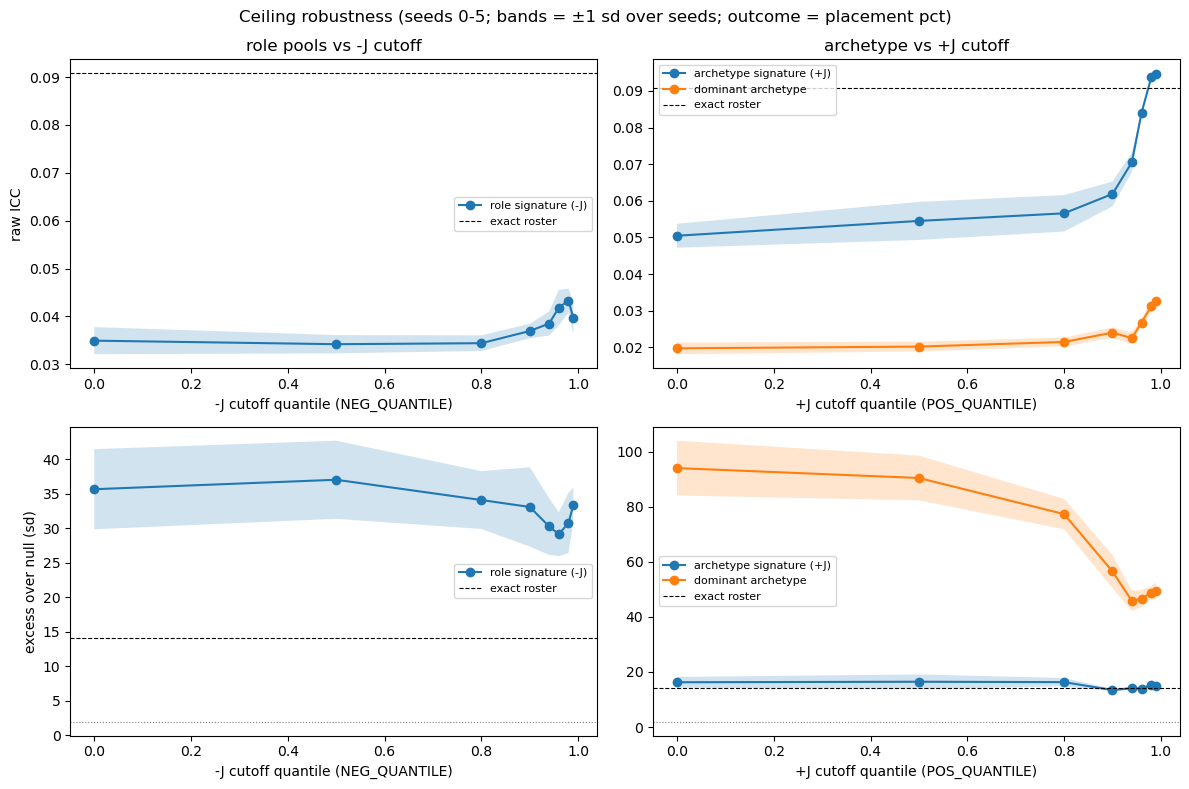

| granularity (placement pct) | ICC (mean ± sd / seeds) | excess (sd) |
| :-- | --: | --: |
| role signature (-J) | 0.0342 ± 0.0019 | +37.0 ± 5.7 |
| archetype signature (+J) | 0.0545 ± 0.0052 | +16.5 ± 2.6 |
| dominant archetype | 0.0202 ± 0.0013 | +90.4 ± 8.1 |
| exact roster | 0.0908 (no seed dep) | +14.1 |

In [6]:
def _band(ax, xs, mat, label):
    mu, sd = np.nanmean(mat, axis=1), np.nanstd(mat, axis=1)
    ax.plot(xs, mu, "o-", label=label)
    ax.fill_between(xs, mu - sd, mu + sd, alpha=0.2)


# Top row: raw ICC (effect size / ceiling height). Bottom row: excess over
# null (significance). Left column sweeps the -J cutoff (role pools); right
# column sweeps the +J cutoff (archetype + dominant). Per-row shared y; axes
# auto-scale (dominant's excess dwarfs the rest because it has ~10 groups, a
# very tight null -- significant, not a taller ceiling).
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
(a_in, a_ip), (a_xn, a_xp) = axes
for ax, mat, ref in ((a_in, role_icc, exact_icc), (a_xn, role_excess, exact_excess)):
    _band(ax, SWEEP_NEG_Q, mat, "role signature (-J)")
    ax.axhline(ref, ls="--", color="k", lw=0.8, label="exact roster")
    ax.set_xlabel("-J cutoff quantile (NEG_QUANTILE)")
a_in.set_ylabel("raw ICC")
a_xn.set_ylabel("excess over null (sd)")
a_xn.axhline(2.0, ls=":", color="gray", lw=0.8)
a_in.set_title("role pools vs -J cutoff")

for ax, am, dm, ref in ((a_ip, arche_icc, dom_icc, exact_icc),
                        (a_xp, arche_excess, dom_excess, exact_excess)):
    _band(ax, SWEEP_POS_Q, am, "archetype signature (+J)")
    _band(ax, SWEEP_POS_Q, dm, "dominant archetype")
    ax.axhline(ref, ls="--", color="k", lw=0.8, label="exact roster")
    ax.set_xlabel("+J cutoff quantile (POS_QUANTILE)")
a_xp.axhline(2.0, ls=":", color="gray", lw=0.8)
a_ip.set_title("archetype vs +J cutoff")
for ax in (a_in, a_ip, a_xn, a_xp):
    ax.legend(fontsize=8)
fig.suptitle(f"Ceiling robustness (seeds {SWEEP_SEEDS[0]}-{SWEEP_SEEDS[-1]}; "
             f"bands = ±1 sd over seeds; outcome = placement pct)")
fig.tight_layout()
plt.show()

# Seed spread at the operating point (POS_QUANTILE, NEG_QUANTILE).
op_neg = SWEEP_NEG_Q.index(NEG_QUANTILE)
op_pos = SWEEP_POS_Q.index(POS_QUANTILE)


def _cell(vals):
    v = np.asarray(vals)
    return f"{np.nanmean(v):.4f} ± {np.nanstd(v):.4f}"


def _zcell(vals):
    v = np.asarray(vals)
    return f"{np.nanmean(v):+.1f} ± {np.nanstd(v):.1f}"


summary = [
    "| granularity (placement pct) | ICC (mean ± sd / seeds) | excess (sd) |",
    "| :-- | --: | --: |",
    f"| role signature (-J) | {_cell(role_icc[op_neg])} | {_zcell(role_excess[op_neg])} |",
    f"| archetype signature (+J) | {_cell(arche_icc[op_pos])} | {_zcell(arche_excess[op_pos])} |",
    f"| dominant archetype | {_cell(dom_icc[op_pos])} | {_zcell(dom_excess[op_pos])} |",
    f"| exact roster | {exact_icc:.4f} (no seed dep) | {exact_excess:+.1f} |",
]
display(Markdown("\n".join(summary)))

## Time-windowed ICC

Pooled ICC credits a model with drift it cannot use: if a roster is good in March and bad in May, pooling counts the March consistency, but an out-of-time model evaluated in May does not get to exploit it. Repeating the measurement inside chronological windows bounds that optimism — the windowed ICC is the figure to compare against out-of-time validation later.


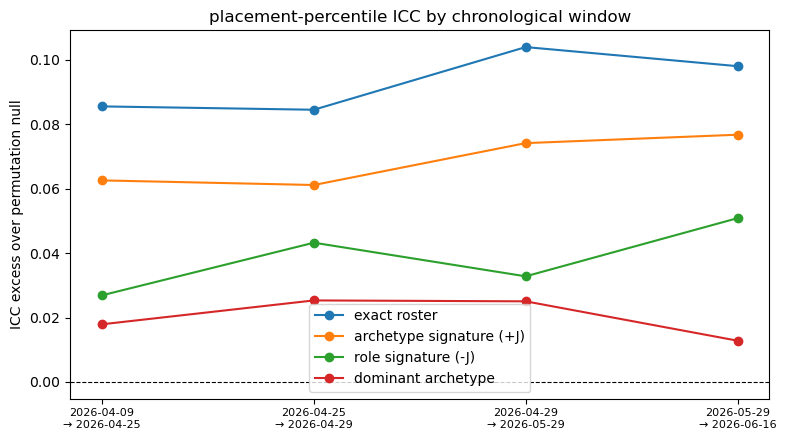

In [ ]:
N_WINDOWS = 4

order = np.argsort(np.array(obs_date, dtype="U10"))
edges = np.linspace(0, len(order), N_WINDOWS + 1).astype(int)

fig, ax = plt.subplots(figsize=(8, 4.5))
window_labels = []
for label, keys in group_keys.items():
    vals = []
    for wi in range(N_WINDOWS):
        sl = order[edges[wi]:edges[wi + 1]]
        observed, null_mu, null_sd = icc_with_null(
            [keys[i] for i in sl], obs_pct[sl].copy(), obs_event[sl], rng)
        vals.append((observed - null_mu) if observed is not None else np.nan)
        if len(window_labels) < N_WINDOWS:
            dates = sorted(obs_date[i] for i in sl)
            window_labels.append(f"{dates[0][:10]}\n→ {dates[-1][:10]}")
    ax.plot(range(N_WINDOWS), vals, "o-", label=label)
ax.axhline(0.0, color="k", lw=0.8, ls="--")
ax.set_xticks(range(N_WINDOWS))
ax.set_xticklabels(window_labels, fontsize=8)
ax.set_ylabel("ICC excess over permutation null")
ax.set_title("placement-percentile ICC by chronological window")
ax.legend()
fig.tight_layout()
plt.show()


## In-person match analog (Bradley-Terry ceiling)

Match-level outcomes are Stage 4's preferred label. Same logic as above: group the per-match win indicators by composition and ask how much win propensity varies across compositions. The permutation null flips each match's winner with probability $\tfrac12$ (exactly the "composition carries no information" world, since each match contributes one win and one loss).

**Swiss caveat:** record-matched pairings compress observed win-rate spread (strong teams meet strong teams), so this ICC is a *conservative lower bound* on the composition signal a matchup-aware model could reach.


In [8]:
match_obs = tournament_ingest.all_match_observations(tournaments, regulation=REGULATION)
print(f"matches: {len(match_obs)}")

# Two rows per match: (composition key, y). Winner flip swaps the two ys.
mk_roster: list = []
mk_signature: list = []
mk_role_sig: list = []
match_y = []
for mo in match_obs:
    for roster, y in ((mo.winner, 1.0), (mo.loser, 0.0)):
        mk_roster.append(roster)
        mk_signature.append(signature(roster))
        mk_role_sig.append(role_signature(roster))
        match_y.append(y)
match_y = np.array(match_y)
n_matches = len(match_obs)


def match_icc_with_null(keys: list, rng: np.random.Generator):
    g = group_codes(keys)
    observed = icc_oneway(g, match_y)
    null = []
    for _ in range(N_PERMUTATIONS):
        flips = rng.random(n_matches) < 0.5
        y_perm = match_y.copy()
        y_perm[0::2][flips] = 1.0 - match_y[0::2][flips]
        y_perm[1::2][flips] = 1.0 - match_y[1::2][flips]
        v = icc_oneway(g, y_perm)
        if v is not None:
            null.append(v)
    return observed, float(np.mean(null)), float(np.std(null))


lines = [
    "| granularity | groups (n≥2) | rows covered | ICC | null mean ± sd | excess (sd) |",
    "| :-- | --: | --: | --: | --: | --: |",
]
for label, keys in (("exact roster", mk_roster),
                    ("archetype signature (+J)", mk_signature),
                    ("role signature (-J)", mk_role_sig)):
    g = group_codes(keys)
    counts = np.bincount(g)
    observed, null_mu, null_sd = match_icc_with_null(keys, rng)
    excess = (observed - null_mu) / null_sd if (observed is not None and null_sd > 0) else float("nan")
    obs_str = f"{observed:.4f}" if observed is not None else "—"
    lines.append(
        f"| {label} | {int((counts >= 2).sum())} | {int(counts[counts >= 2].sum())} "
        f"| {obs_str} | {null_mu:.4f} ± {null_sd:.4f} | {excess:+.1f} |"
    )
display(Markdown("\n".join(lines)))


TypeError: all_match_observations() got an unexpected keyword argument 'regulation'

### Round-resolved match ICC (Swiss de-confounding)

The pooled match ICC above is Swiss-compressed: by round 4-5 strong teams are paired against strong teams, so composition's contribution to *who wins* is attenuated by range restriction. **Round 1 is the unconfounded slice** — everyone is 0-0, pairings aren't record-matched yet, so a round-1 ICC isolates the composition signal without the compression. A decay of per-round ICC from round 1 onward would confirm the mechanism.

Caveat that matters today: one round is ~`players/2` matches, so round 1 alone is low-powered (the pooled significance came from N, not per-round effect size). Read this as a **trend plus a check to refresh as in-person events accrue** — each new major roughly doubles the round-1 sample. Later attenuation is range restriction (estimates pulled toward zero), not upward bias, so later rounds stay conservative; we therefore report round 1 / early-pool / all-rounds rather than down-weighting later rounds by a guessed decay.

In [ ]:
# Round 1 is unconfounded; later day-1 rounds attenuate under record-matching.
# Day-2 global rounds (9+) and top cut are too thin to read here.
EARLY_ROUNDS = 3      # "early" pool = rounds 1..EARLY_ROUNDS
DAY1_MAX_ROUND = 8    # day-1 swiss; later global rounds are day-2 (record-gated, thin)
ROUND_N_PERM = 300


def match_icc_subset(matches, keyfn, rng, n_perm=ROUND_N_PERM):
    """(raw ICC, excess in null-sd units, n_matches) on a match subset, with the
    winner-flip null. keyfn maps a roster frozenset to its grouping key."""
    if not matches:
        return np.nan, np.nan, 0
    keys, y = [], []
    for m in matches:
        keys.append(keyfn(m.winner)); y.append(1.0)
        keys.append(keyfn(m.loser)); y.append(0.0)
    y = np.asarray(y)
    g = group_codes(keys)
    obs = icc_oneway(g, y)
    if obs is None:
        return np.nan, np.nan, len(matches)
    n = len(matches)
    null = []
    for _ in range(n_perm):
        flips = rng.random(n) < 0.5
        yp = y.copy()
        yp[0::2][flips] = 1.0 - y[0::2][flips]
        yp[1::2][flips] = 1.0 - y[1::2][flips]
        v = icc_oneway(g, yp)
        if v is not None:
            null.append(v)
    null = np.asarray(null)
    sd = null.std()
    return obs, ((obs - null.mean()) / sd if sd > 0 else np.nan), n


by_round = defaultdict(list)
for mo in match_obs:
    by_round[mo.round].append(mo)
print("matches per day-1 round:",
      {r: len(by_round[r]) for r in range(1, DAY1_MAX_ROUND + 1)})

# Per-round trend across day-1 swiss (excess over null).
rounds = [r for r in range(1, DAY1_MAX_ROUND + 1) if len(by_round[r]) >= 50]
arche_curve = [match_icc_subset(by_round[r], signature, np.random.default_rng(700 + r))
               for r in rounds]
role_curve = [match_icc_subset(by_round[r], role_signature, np.random.default_rng(800 + r))
              for r in rounds]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(rounds, [a[1] for a in arche_curve], "o-", label="archetype signature (+J)")
ax.plot(rounds, [r[1] for r in role_curve], "s-", label="role signature (-J)")
ax.axhline(0.0, color="k", lw=0.8)
ax.axhline(2.0, ls=":", color="gray", lw=0.8)
ax.set_xlabel("day-1 swiss round")
ax.set_ylabel("match-ICC excess over null (sd)")
ax.set_title("Composition signal by round (round 1 unconfounded; decay = Swiss compression)")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

# Round 1 / early pool / full corpus, all three granularities.
slices = {
    "round 1 only": by_round[1],
    f"rounds 1-{EARLY_ROUNDS}": [m for r in range(1, EARLY_ROUNDS + 1) for m in by_round[r]],
    "all rounds": match_obs,
}
tbl = ["| slice | n matches | exact ICC (excess) | archetype ICC (excess) | role ICC (excess) |",
       "| :-- | --: | --: | --: | --: |"]
for si, (label, ms) in enumerate(slices.items()):
    ex = match_icc_subset(ms, lambda r: r, np.random.default_rng(900 + si))
    ar = match_icc_subset(ms, signature, np.random.default_rng(920 + si))
    ro = match_icc_subset(ms, role_signature, np.random.default_rng(940 + si))
    tbl.append(f"| {label} | {len(ms)} | {ex[0]:.4f} ({ex[1]:+.1f}) "
               f"| {ar[0]:.4f} ({ar[1]:+.1f}) | {ro[0]:.4f} ({ro[1]:+.1f}) |")
display(Markdown("\n".join(tbl)))

## Does match volume support pairwise $\Delta J$?

Stage 4 restricts $\Delta J$ support to feature pairs co-occurring at least $k$ times in the outcome corpus. Count that support directly: within-team co-occurrence of species@item vocab pairs across the teams that actually played matches (each team counted once per match played, since that is its effective sample size in the BT likelihood).


In [ ]:
pair_vocab_counts: Counter = Counter()
for mo in match_obs:
    for roster in (mo.winner, mo.loser):
        members = sorted(roster)
        for a, b in itertools.combinations(members, 2):
            pair_vocab_counts[(a, b)] += 1

support = np.array(sorted(pair_vocab_counts.values(), reverse=True))
print(f"distinct co-occurring feature pairs in the match corpus: {len(support)}")
for k in (5, 10, 20, 50):
    print(f"  pairs with support >= {k:3d}: {(support >= k).sum():6d}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(np.log10(support), bins=50)
ax.set_xlabel("log10(pair support)")
ax.set_ylabel("feature pairs")
ax.set_title("ΔJ pair support in the in-person match corpus")
fig.tight_layout()
plt.show()


## Reading the gate

**Result (Reg M-A; Limitless + 2 in-person events, 2026-06-13).** Gate **passes** — a small but robust composition ceiling on placement, field-$\Delta h$-leaning; the match/BT path is data-starved for now.

- **Placement percentile (the well-powered label):** archetype-signature ICC $\approx 0.036$, role-signature $\approx 0.028$, stable across the full cutoff range and 6 Louvain seeds (the robustness sweep), $+20$ to $+50$ sd over null. Exact roster $0.086$ but inflated by near-singleton groups; the high-cutoff spike toward it is fragmentation, not signal. So the honest ceiling is **$\approx$3-4% of placement-percentile variance**: real, modest, archetype/role-grained.
- **Match outcome (per game):** pooled ICC $\approx 0.01$ (archetype $+4.3$, role $+6.5$ sd via N); **null at exact-roster grain** ($+1.4$ sd). Round-1 (unconfounded) point estimates run 2-3x higher (archetype $0.031$, exact $0.022$) in the predicted de-attenuation direction, but underpowered at $n\approx970$. The match ceiling is lower than placement and only coarse-grained — a single game is noisier than a 15-round placement.
- **$\Delta J$ feasibility:** 834 feature pairs co-occur $\ge 50$ times in the match corpus, 1657 $\ge 20$ — enough to *estimate* a support-gated $\Delta J$, but the match label doesn't resolve fine composition, so fitting it is upstream of the data.

**Decision:** build Stage 4 on **placement percentile** (primary label) with a **field-$\Delta h$-dominant** parameterization; treat pairwise $\Delta J$ as a thin, support-gated second pass. **Park the BT/match path** until more in-person events land (re-run the round-resolved cell as a trigger — NAIC and each subsequent major roughly double the round-1 sample).

---

Decision tree (kept as the general interpretation guide):

- **Placement/match ICC indistinguishable from the permutation null at every granularity** → the ceiling is negligible: no composition-only goodness model can work, Stage 4/5 stop here, and the null result becomes a `/science` writeup (it is a real finding — composition determines *what people bring*, not *who wins*, consistent with `outcome_validation.ipynb`'s coherence-vs-placement null).
- **Meaningful excess at archetype/role granularity but not exact roster** → the goodness signal exists but lives at coarse resolution; Stage 4 should expect most of its juice in $\Delta h$ (and coarse structure), with the windowed ICC as the out-of-time target to quote.
- **Archetype signature vs. role signature** → the two coarse keys decompose *where* coarse goodness lives: archetype excess means it matters *which archetype you commit to* (a $\Delta h$-shaped story — the winning meta overweights certain cores); role excess means it matters *how the six slots are covered* (closer to a $\Delta J$-shaped story — winning teams combine roles differently than the played meta). If both move together they are likely seeing the same teams through two partitions; check whether the role key separates teams *within* one archetype before reading them as independent signals.
- **Meaningful excess at roster granularity too** → proceed to Stage 4 with the full parameterization; the ceiling number is the denominator for "fraction of ceiling captured" in `goodness_recovery.ipynb`.
- **$\Delta J$ support table** → if only a few hundred pairs clear $k \ge 10$–20, fit field-only $\Delta h$ first and add $\Delta J$ on the supported subset as a second pass; if support is broad, the pairwise term is on the table from the start.

Caveats: in-person match ICC is Swiss-compressed (conservative; see the round-resolved cell); pooled placement ICC is drift-inflated (use the windowed numbers for out-of-time expectations); both signature keys depend on the Louvain partition (seeded, but not unique — the sweep shows stability), and the role key additionally depends on the $-J$ threshold quantile.